# Vector Auto Regresive (VAR)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

# Experiment

In [6]:
df_var = df[['date',  'dengue', 'tavg',
       'prcp', 'wspd', 'pres', 'mob_index', 
       'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
df_var.set_index('date', inplace=True)

In [14]:
# train test split chronologically 80/20
df_train = df_var[:int(0.8*len(df_var))]

In [7]:
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

In [15]:
# Fit a VAR model
model = VAR(df_train)
results = model.fit(maxlags=5)  # Choose lag length (5 lags)
print(results.summary())

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 08, May, 2025
Time:                     11:15:18
--------------------------------------------------------------------
No. of Equations:         15.0000    BIC:                    31.9374
Nobs:                     152.000    HQIC:                   18.4714
Log likelihood:          -2798.81    FPE:                    46051.0
AIC:                      9.25832    Det(Omega_mle):         105.165
--------------------------------------------------------------------
Results for equation dengue
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                 -11265.096658      9139.953679           -1.233           0.218
L1.dengue                  0.559754         0.132424            4.227           0.000
L1.tavg                  -10.761894    

In [16]:
# log of variables
df_var_log = np.log(df_train).diff()
df_var_log.dropna(inplace=True)
df_var_log.head()


,dengue,tavg,prcp,wspd,pres,mob_index,google_hospital,google_pharmacy,google_symptom,humidity,no2,o3,pm10,pm25,so2
date,,,,,,,,,,,,,,,
2020-03-30,0.058329,0.015243,0.908115,-0.040540,-0.000583,-0.550255,-0.223144,0.000000,-0.095310,-0.029766,-0.139961,-0.328942,-0.661490,-0.626573,-0.167054
2020-04-06,-0.077478,0.012587,-0.424269,0.047019,0.000834,-0.473495,0.000000,0.000000,-0.051293,-0.001435,-0.281584,-0.104874,-0.505176,-0.527920,-0.022990
2020-04-13,-0.052934,-0.049995,-0.301046,-0.073326,0.001669,-0.313713,0.000000,-0.182322,-0.203599,0.038830,0.398348,0.028154,0.730018,0.696017,0.045462
2020-04-20,-0.004540,0.013635,0.727325,-0.104346,-0.000843,0.110046,-0.133531,0.000000,-0.066691,0.005254,0.027178,-0.230108,-0.313658,-0.334945,-0.372675
2020-04-27,-0.092924,0.022462,-0.703587,0.106406,-0.000401,0.182322,0.133531,0.000000,0.000000,-0.035503,0.153441,-0.049534,0.062989,0.040555,0.092373


In [17]:
# Fit a VAR model
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
results_l.summary()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 08, May, 2025
Time:                     11:15:28
--------------------------------------------------------------------
No. of Equations:         15.0000    BIC:                   -57.5726
Nobs:                     151.000    HQIC:                  -71.0978
Log likelihood:           3992.68    FPE:                5.76054e-35
AIC:                     -80.3520    Det(Omega_mle):     1.27271e-37
--------------------------------------------------------------------
Results for equation dengue
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.006953         0.007955            0.874           0.382
L1.dengue                 -0.220186         0.099625           -2.210           0.027
L1.tavg                   -0.150699    

# All countries

In [18]:
def extract_significant_vars(results, target, alpha=0.05):
    # Get the parameters, standard errors, t-statistics, and p-values

    
    params = results.params[target]
    stderr = results.stderr[target]
    tvalues = results.tvalues[target]
    pvalues = results.pvalues[target]

    # Combine into a DataFrame
    df = pd.DataFrame({
        'Variable': params.index,
        'Coefficient': params.values,
        'Std. Error': stderr.values,
        't-value': tvalues.values,
        'P-value': pvalues.values
    })

        # Filter significant variables (p-value < alpha)
    significant_df = df[df['P-value'] < alpha]

    return significant_df


In [19]:
df_coefficients =  extract_significant_vars(results_l, 'dengue')
df_coefficients[df_coefficients['P-value'] < 0.05][['Variable', 'Coefficient', 'P-value']]

,Variable,Coefficient,P-value
1,L1.dengue,-0.220186,0.027095
10,L1.humidity,-1.417750,0.003633
16,L2.dengue,0.235279,0.025915
31,L3.dengue,0.245319,0.025281
35,L3.pres,36.092484,0.001784
37,L3.google_hospital,-0.287240,0.012899
61,L5.dengue,0.203742,0.049074
62,L5.tavg,-1.701206,0.013546
70,L5.humidity,1.558119,0.000918
71,L5.no2,-0.204539,0.015240


In [12]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [13]:
targets = [ 'dengue', 'zika', 'chik', 'var']
for col in targets:
    df[col+'_cumulative'] = np.cumsum(df[col])

In [ ]:
#targets = [ 'dengue', 'zika', 'chik', 'var']
targets = [ 'dengue', 'zika', 'chik', 'var']

dict_results = {}
#target = 'new_cases'
# loop mock
for target in targets:
    print(target)
    df_var = df[['date',  target, 'tavg',
       'prcp', 'wspd', 'pres', 'mob_index', 
       'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
    df_var.set_index('date', inplace=True)
    df_var[target] = df_var[target].replace(0,1)
    df_var_log = np.log(df_var).diff()
    df_var_log.dropna(inplace=True)
    model_l = VAR(df_var_log)
    results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
    significant_vars_cases = extract_significant_vars(results_l, target=target, alpha=0.05)
    dict_results[target] = significant_vars_cases['Variable'].values


dengue_cumulative
zika_cumulative
chik_cumulative
var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_28240\834916591.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = df_var[target].replace(0,1)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_28240\834916591.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = df_

In [15]:
df_results = pd.DataFrame.from_dict(dict_results, orient='index').T
df_results

,dengue_cumulative,zika_cumulative,chik_cumulative,var_cumulative
0,const,const,const,const
1,L1.dengue_cumulative,L1.zika_cumulative,L2.pres,L1.var_cumulative
2,L2.dengue_cumulative,L1.prcp,L3.chik_cumulative,L1.pm10
3,L3.pres,L1.pres,L5.chik_cumulative,L1.pm25
4,L3.google_hospital,L1.pm10,None,L3.pm10
5,L5.tavg,L1.pm25,None,L3.pm25
6,L5.humidity,L2.zika_cumulative,None,L4.o3
7,None,L2.google_pharmacy,None,None
8,None,L3.zika_cumulative,None,None
9,None,L3.so2,None,None


In [16]:
target = 'dengue_cumulative'


df_var = df[['date',  target, 'tavg',  'humidity','pres', 'google_hospital']]
df_var.set_index('date', inplace=True)

df_var[target] = df_var[target].replace(0,1)
df_var_log = np.log(df_var).diff()
df_var_log.dropna(inplace=True)
model_l = VAR(df_var_log)
results_l = model_l.fit(maxlags=5)  # Choose lag length (5 lags)
irf = results_l.irf(10)


C:\Users\danie\AppData\Local\Temp\ipykernel_28240\4281860600.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var[target] = df_var[target].replace(0,1)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


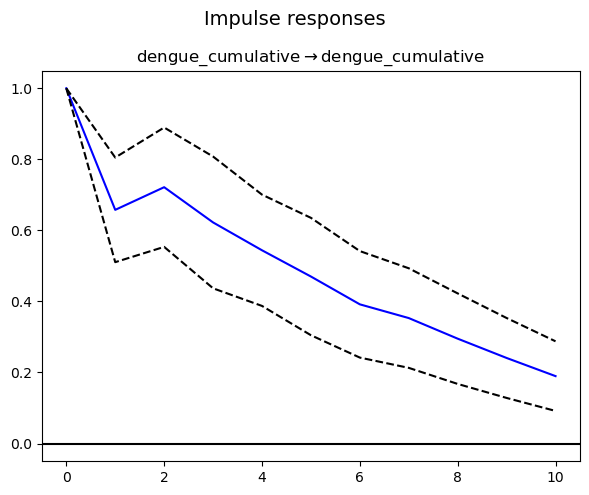

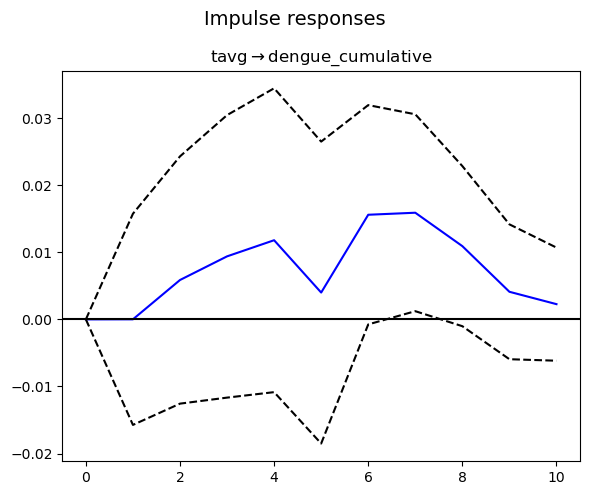

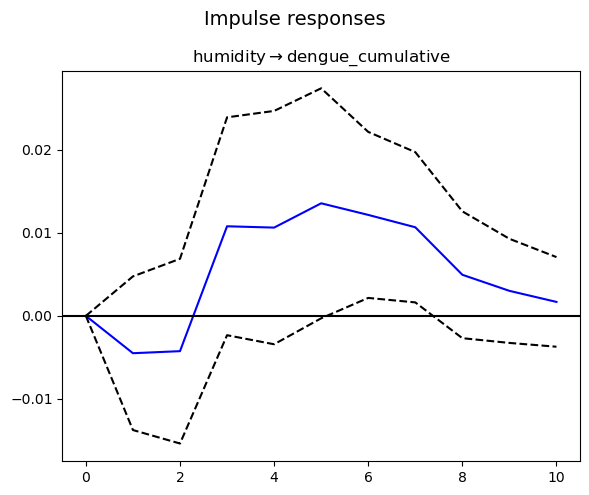

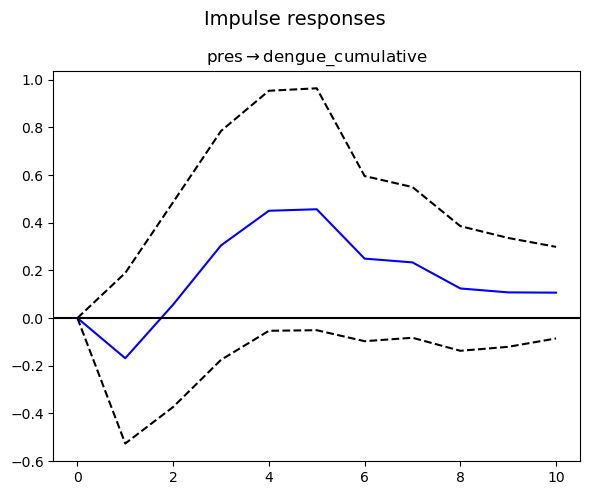

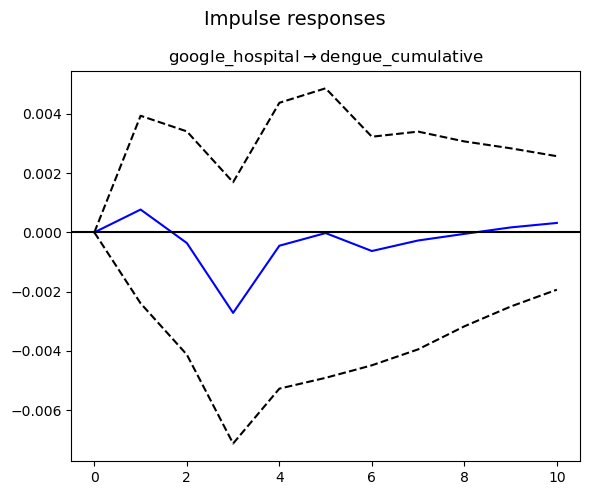

In [17]:
impulses = [ target, 'tavg',  'humidity','pres', 'google_hospital']
response = target  # e.g., 'dengue'

for imp in impulses:
    irf.plot(impulse=imp, response=response, figsize=(6, 5))  # smaller plot size
    plt.tight_layout()

    


# Train Test split

Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_28240\955289747.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_28240\955289747.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: N

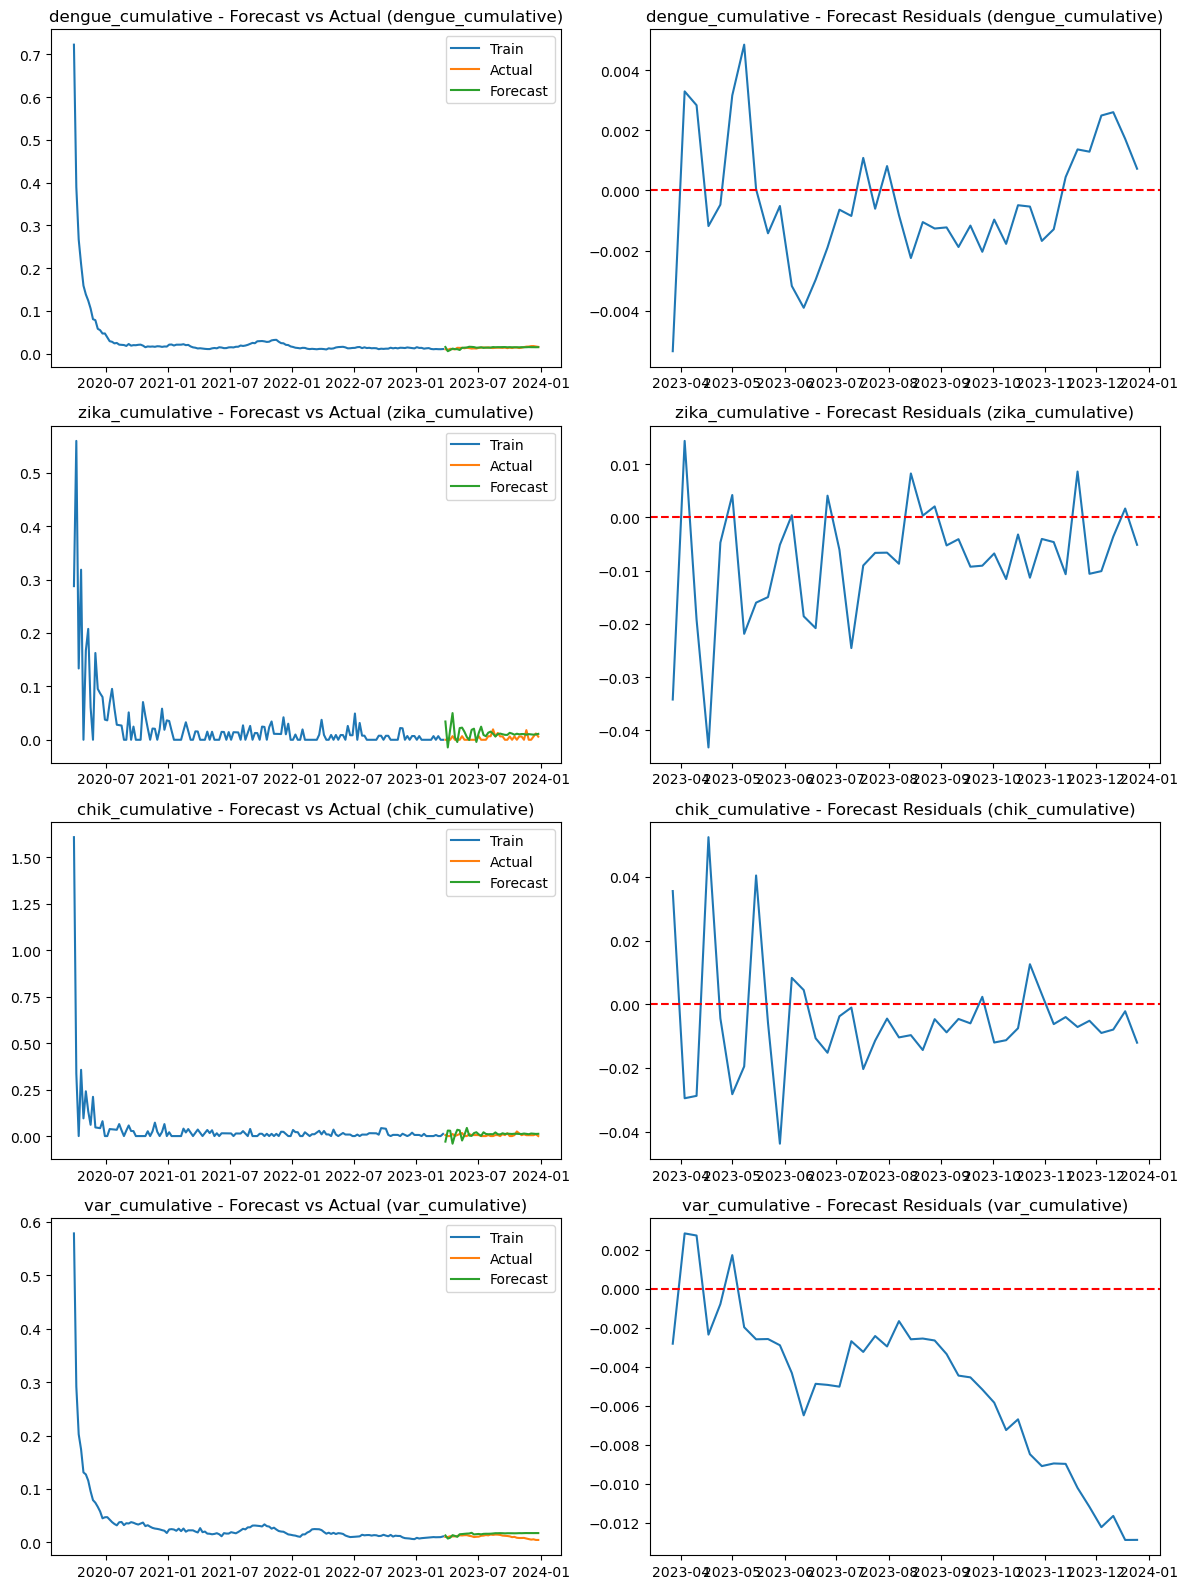

In [18]:
from sklearn.metrics import mean_squared_error, r2_score


dict_metrics = {}

fig, axs = plt.subplots(len(targets), 2, figsize=(12, 4 * len(targets)))

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_df = pd.DataFrame(forecast, index=df_test.index, columns=df_test.columns)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(df_test[target], forecast_df[target]))
    r2 = r2_score(df_test[target], forecast_df[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable
    axs[idx, 0].plot(df_train[target], label='Train')
    axs[idx, 0].plot(df_test[target], label='Actual')
    axs[idx, 0].plot(forecast_df[target], label='Forecast')
    axs[idx, 0].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals
    residuals = df_test[target] - forecast_df[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{target} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [19]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
dengue_cumulative,0.002088,-0.229176
zika_cumulative,0.013608,-6.348989
chik_cumulative,0.018049,-9.426633
var_cumulative,0.006362,-4.106756


Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_28240\2670918325.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_28240\2670918325.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

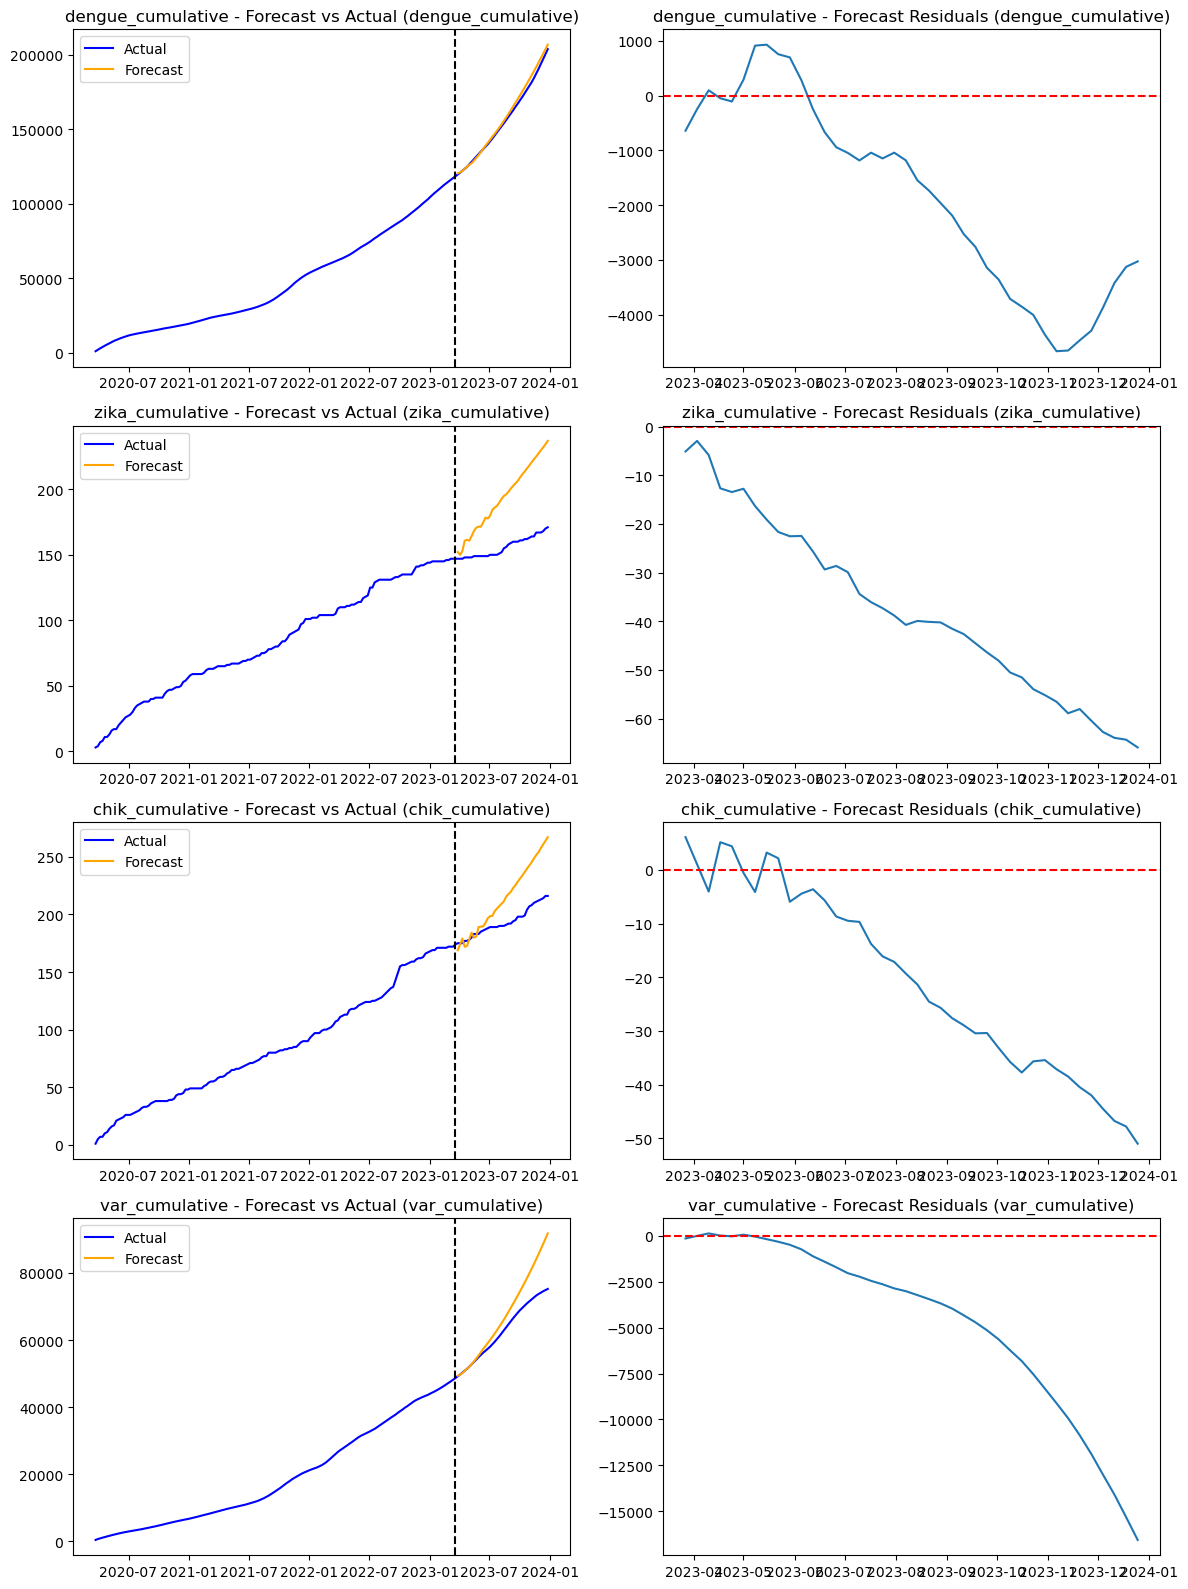

In [20]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt



dict_metrics = {}


fig, axs = plt.subplots(len(targets), 2, figsize=(12, 4 * len(targets)))

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # filter by country
    

     # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx, 0].plot(df_original[target], label='Actual', color='blue')
    axs[idx, 0].plot(forecast_original_scale[target], label='Forecast', color='orange')
    axs[idx, 0].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx, 0].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx, 0].legend()

    # Plot residuals in original scale
    residuals = actual_original_scale[target] - forecast_original_scale[target]
    axs[idx, 1].plot(residuals)
    axs[idx, 1].axhline(y=0, color='r', linestyle='--')
    axs[idx, 1].set_title(f'{target} - Forecast Residuals ({target})')

plt.tight_layout()
plt.show()

In [21]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df

,rmse,r2
dengue_cumulative,2514.273970,0.989552
zika_cumulative,41.566466,-28.852207
chik_cumulative,26.659359,-3.754705
var_cumulative,6570.407801,0.381293


Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


C:\Users\danie\AppData\Local\Temp\ipykernel_28240\422756588.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\danie\AppData\Local\Temp\ipykernel_28240\422756588.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.replace(0, 1, inplace=True)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: N

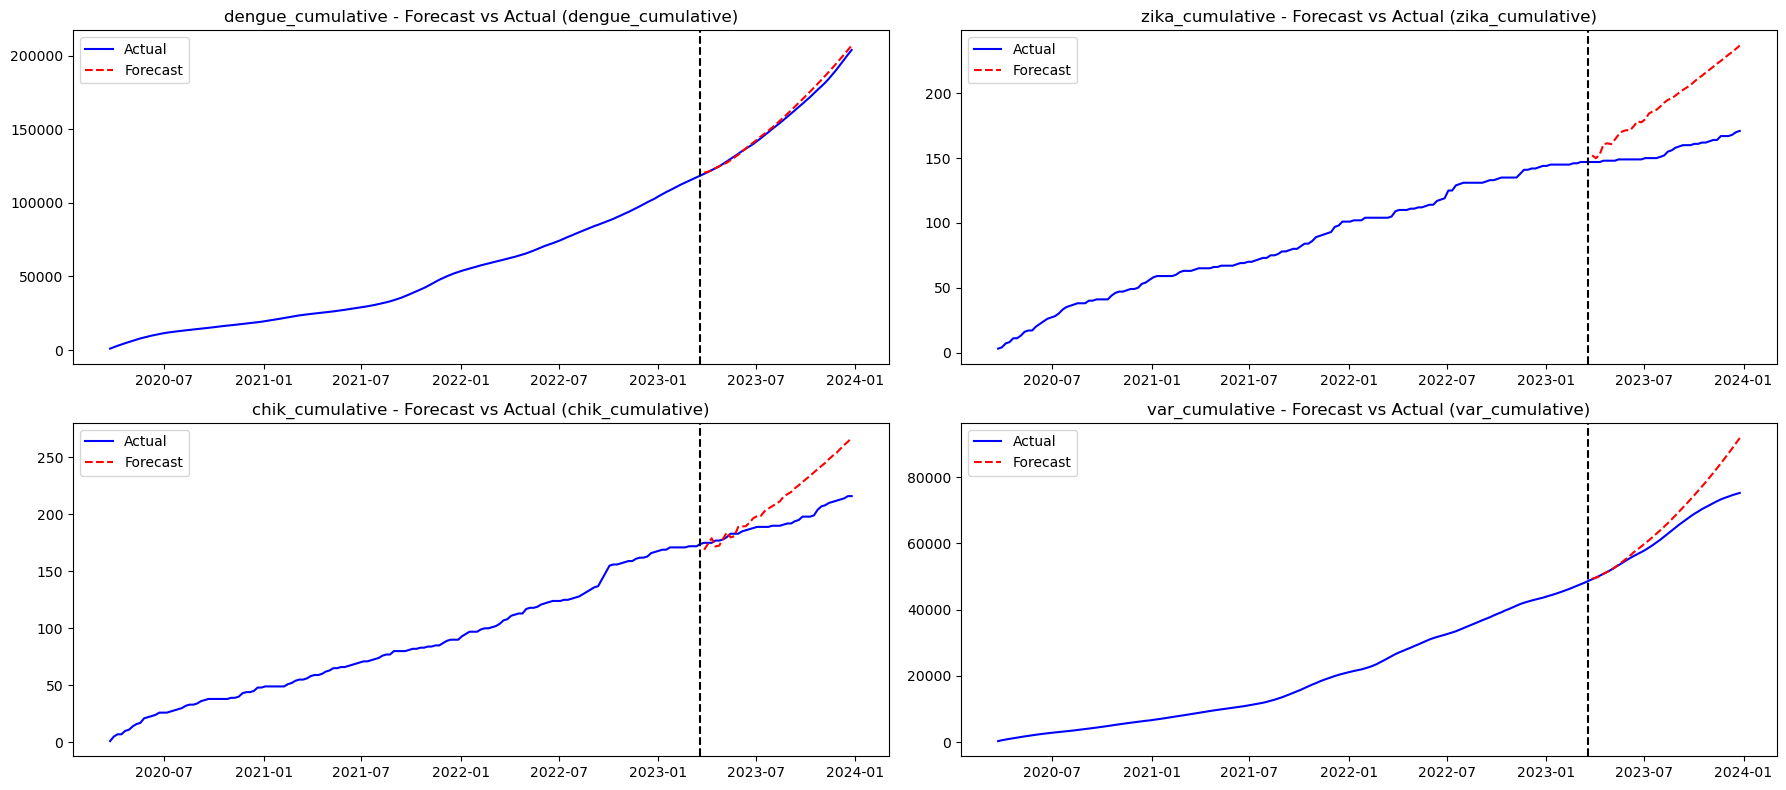

In [22]:


dict_metrics = {}


fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    

    # select columns
    # select variables
    df_var = df[['date',  target, 'tavg',
    'prcp', 'wspd', 'pres', 'mob_index', 
    'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
    df_var.set_index('date', inplace=True)

    
    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}


    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(targets), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [23]:
# Display metrics
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
dengue_cumulative,2514.273970
zika_cumulative,41.566466
chik_cumulative,26.659359
var_cumulative,6570.407801


## Feature Selection

In [24]:
dict_results

{'dengue_cumulative': array(['const', 'L1.dengue_cumulative', 'L2.dengue_cumulative', 'L3.pres',
        'L3.google_hospital', 'L5.tavg', 'L5.humidity'], dtype=object),
 'zika_cumulative': array(['const', 'L1.zika_cumulative', 'L1.prcp', 'L1.pres', 'L1.pm10',
        'L1.pm25', 'L2.zika_cumulative', 'L2.google_pharmacy',
        'L3.zika_cumulative', 'L3.so2', 'L4.zika_cumulative'], dtype=object),
 'chik_cumulative': array(['const', 'L2.pres', 'L3.chik_cumulative', 'L5.chik_cumulative'],
       dtype=object),
 'var_cumulative': array(['const', 'L1.var_cumulative', 'L1.pm10', 'L1.pm25', 'L3.pm10',
        'L3.pm25', 'L4.o3'], dtype=object)}

Processing disease: dengue_cumulative
Processing disease: zika_cumulative
Processing disease: chik_cumulative
Processing disease: var_cumulative


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


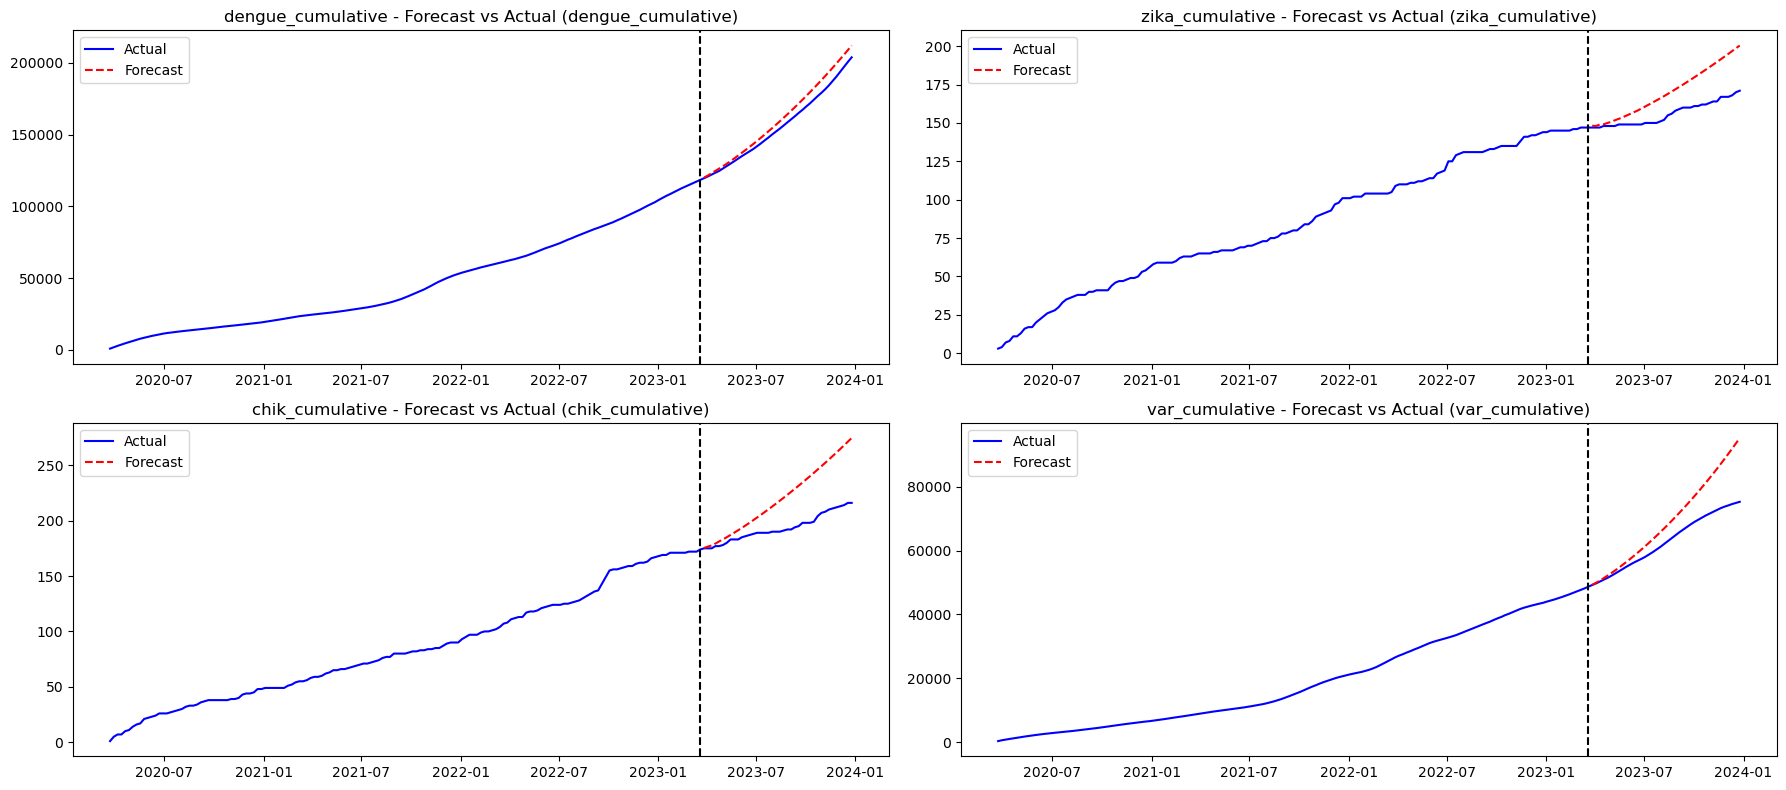

In [25]:




dict_metrics = {}

fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()

for idx, target in enumerate(targets):
    print(f"Processing disease: {target}")

    # filter by country
    df_var = df.copy()

    # select columns based on significant variables
    significant_vars = dict_results[target]

    columns_to_use = ['date', target]

    # Add relevant original variables (without lag prefix)
    available_vars = ['tavg', 'prcp', 'wspd', 'pres', 'mob_index', 
                      'google_hospital', 'google_pharmacy', 'google_symptom', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']

    # track whether at least one explanatory var is added
    explanatory_added = False

    for var in available_vars:
        if any(var in sig_var for sig_var in significant_vars):
            columns_to_use.append(var)
            if var != target:
                explanatory_added = True

    # If no explanatory variables were added, force inclusion of 'tavg'
    if not explanatory_added and 'tavg' not in columns_to_use:
        print(f"Target '{target}' depends only on itself, forcing inclusion of 'tavg'")
        columns_to_use.append('tavg')

    df_var = df_var[columns_to_use].copy()

    df_var.set_index('date', inplace=True)

    # replace 0 to avoid log error
    df_var.replace(0, 1, inplace=True)

    df_original = df_var.copy()

    # log difference
    df_var_log = np.log(df_var).diff().dropna()

    # train-test split
    split_idx = int(len(df_var_log) * 0.8)
    df_train, df_test = df_var_log.iloc[:split_idx], df_var_log.iloc[split_idx:]

    # fit VAR model on training data
    model_l = VAR(df_train)
    results_l = model_l.fit(maxlags=5)

    # Forecasting
    lag_order = results_l.k_ar
    forecast_input = df_train.values[-lag_order:]
    forecast_steps = len(df_test)

    forecast_diff_log = results_l.forecast(y=forecast_input, steps=forecast_steps)
    forecast_diff_log_df = pd.DataFrame(forecast_diff_log, index=df_test.index, columns=df_test.columns)

    # Reverse transformations to original scale
    last_observed_log = np.log(df_original.iloc[split_idx])
    forecast_log = forecast_diff_log_df.cumsum() + last_observed_log
    forecast_original_scale = np.exp(forecast_log)
    actual_original_scale = df_original.iloc[split_idx+1:split_idx+1+forecast_steps]

    # Calculate performance metrics on original scale
    rmse = np.sqrt(mean_squared_error(actual_original_scale[target], forecast_original_scale[target]))
    r2 = r2_score(actual_original_scale[target], forecast_original_scale[target])

    dict_metrics[target] = {'rmse': rmse, 'r2': r2}

    # Plot actual vs forecast for target variable in original scale
    axs[idx].plot(df_original[target], label='Actual', color='blue')
    axs[idx].plot(forecast_original_scale[target], label='Forecast', color='red', linestyle='--')
    axs[idx].axvline(df_original.index[split_idx], color='black', linestyle='--')
    axs[idx].set_title(f'{target} - Forecast vs Actual ({target})')
    axs[idx].legend()

# Adjust layout and remove any unused subplots
for j in range(len(targets), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()




In [26]:
metrics_df = pd.DataFrame(dict_metrics).T
metrics_df[['rmse']]

,rmse
dengue_cumulative,5855.042743
zika_cumulative,16.767235
chik_cumulative,31.725518
var_cumulative,8510.949641


## Hybrid model

1. Fit a GGM on each country
2. Use that as a covariate 
3. Fit a VAR using the GGM fitted values as covariate
4. See the results